# Titanic - Machine Learning from Disaster

#### Path settings

In [7]:
from pathlib import Path
import os

class Config:
    # 環境判定
    IS_KAGGLE = bool(os.getenv("KAGGLE_URL_BASE"))

    # ルート
    ROOT = Path("/kaggle/working") if IS_KAGGLE else Path.cwd()

    # データ
    DATA = Path("/kaggle/input/titanic") if IS_KAGGLE else ROOT / "data/raw"

    # 出力
    OUTPUT = ROOT / "output"
    OUTPUT.mkdir(exist_ok=True)

    # DB
    DB = ROOT / "titanic.duckdb" if IS_KAGGLE else ROOT / "data/db/titanic.duckdb"

    print(ROOT)
    print(DATA)
    print(OUTPUT)
    print(DB)

# kaggleで試したとき
# /kaggle/working
# /kaggle/input/titanic
# /kaggle/working/output
# /kaggle/working/titanic.duckdb

c:\Git\kaggle\titanic
c:\Git\kaggle\titanic\data\raw
c:\Git\kaggle\titanic\output
c:\Git\kaggle\titanic\data\db\titanic.duckdb


In [8]:
import duckdb
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

#### CREATE TABLE (train and test)

In [10]:
# DuckDBに接続
conn = duckdb.connect(Config.DB)

def create_train():
    # trainデータをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE train AS
        SELECT *
        FROM read_csv_auto('{Config.DATA}/train.csv')
    """)


def create_test():
    # testデータをテーブルに
    conn.execute(f"""
        CREATE OR REPLACE TABLE test AS
        SELECT *
        FROM read_csv_auto('{Config.DATA}/test.csv')
    """)

In [12]:
train = conn.sql("SELECT * FROM train").pl()
test = conn.sql("SELECT * FROM test").pl()

# まずはデータの行数と列数を確認
print(f"train: {train.shape}")
print(f"test: {test.shape}")

# 表を並べて確認する
display(train.head(), test.head())

train: (891, 12)
test: (418, 11)


PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,i64,str,str,f64,i64,i64,str,f64,str,str
1,0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
2,1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
3,1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
4,1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
5,0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""


PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
i64,i64,str,str,f64,i64,i64,str,f64,str,str
892,3,"""Kelly, Mr. James""","""male""",34.5,0,0,"""330911""",7.8292,null,"""Q"""
893,3,"""Wilkes, Mrs. James (Ellen Need…","""female""",47.0,1,0,"""363272""",7.0,null,"""S"""
894,2,"""Myles, Mr. Thomas Francis""","""male""",62.0,0,0,"""240276""",9.6875,null,"""Q"""
895,3,"""Wirz, Mr. Albert""","""male""",27.0,0,0,"""315154""",8.6625,null,"""S"""
896,3,"""Hirvonen, Mrs. Alexander (Helg…","""female""",22.0,1,1,"""3101298""",12.2875,null,"""S"""


#### CREATE join data
- テストデータはSurvivedがなくカラムが1つ少ないことを確認
- Ageの型がFloatになってる。切り捨てINTに変更する
- Fareの型もFloatだけど、こちらは四捨五入にしておくことにする

In [13]:
def create_join_data():
    # 結合データをテーブルに
    train = conn.sql("SELECT * FROM train")
    test = conn.sql("SELECT * FROM test")

    conn.execute(f"""
        CREATE OR REPLACE TABLE join_data AS
        ( SELECT
            PassengerId,Survived,Pclass,Name,Sex,CAST(Age AS INTEGER) as Age,SibSp,Parch,Ticket,ROUND(Fare, 1) as Fare,Cabin,Embarked
        FROM train
        UNION ALL
        SELECT
            PassengerId,NULL as Survived,Pclass,Name,Sex,CAST(Age AS INTEGER) as Age,SibSp,Parch,Ticket,ROUND(Fare, 1) as Fare,Cabin,Embarked
        FROM test )
        """)

In [14]:
join_data = conn.sql("SELECT * FROM join_data").pl()

# 結合データのサマリを確認
print(join_data.describe())

shape: (9, 13)
┌────────────┬─────────────┬──────────┬──────────┬─────────────────────────────┬────────┬───────────┬──────────┬──────────┬───────────┬───────────┬───────┬──────────┐
│ statistic  ┆ PassengerId ┆ Survived ┆ Pclass   ┆ Name                        ┆ Sex    ┆ Age       ┆ SibSp    ┆ Parch    ┆ Ticket    ┆ Fare      ┆ Cabin ┆ Embarked │
│ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---                         ┆ ---    ┆ ---       ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---   ┆ ---      │
│ str        ┆ f64         ┆ f64      ┆ f64      ┆ str                         ┆ str    ┆ f64       ┆ f64      ┆ f64      ┆ str       ┆ f64       ┆ str   ┆ str      │
╞════════════╪═════════════╪══════════╪══════════╪═════════════════════════════╪════════╪═══════════╪══════════╪══════════╪═══════════╪═══════════╪═══════╪══════════╡
│ count      ┆ 1309.0      ┆ 891.0    ┆ 1309.0   ┆ 1309                        ┆ 1309   ┆ 1046.0    ┆ 1309.0   ┆ 1309.0   ┆ 1309      ┆ 1308.0    ┆ 29

#### 気になったことなどをメモする
- 欠損値　→　年齢、値段、客室、港　特に客室情報は抜けが多い <br>
　　→　客室情報は抜けが多いから落としてしまった方がいいかも <br>
- 年齢は普通に平均で埋めちゃったらまずそう。なにか他の値を参考にできないか <br>
　　→　MrとかMrsとかついてるので、その平均で埋めれるのでは？もしくは平均と中央値があんまり離れてるならどちらを採用するかも考えたほうがいいかも <br>
- 映画で見たら、お金持ちから助かったっぽいイメージ。チケットの値段からお金持ちかどうかわかるかも？ <br>
　　→　相関を見ておく。ところで、チケット代のminが0円…タダってこと？なんで？従業員？？？ <br>
- 出向した港は、0.15%の欠損だけど、なんとなく生存率には関係ないのでは？ <br>
　　→　相関を見ておく <br>


In [21]:
# 相関を見ておく
corr = join_data.select(
    pl.corr("Sex", "Survived"),
    pl.corr("Age", "Survived"),
    pl.corr("Fare", "Survived"),
    pl.corr("Pclass", "Survived"),
    pl.corr("SibSp", "Survived")
)
print(corr)



shape: (1, 5)
┌─────┬───────────┬──────────┬───────────┬───────────┐
│ Sex ┆ Age       ┆ Fare     ┆ Pclass    ┆ SibSp     │
│ --- ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ f64 ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════╪═══════════╪══════════╪═══════════╪═══════════╡
│ NaN ┆ -0.076834 ┆ 0.257276 ┆ -0.338481 ┆ -0.035322 │
└─────┴───────────┴──────────┴───────────┴───────────┘


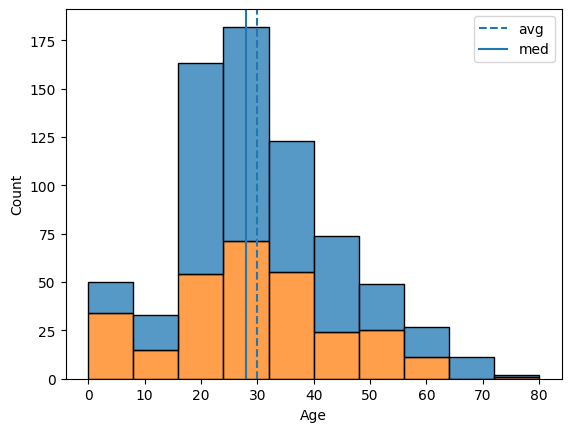

In [4]:
# 年齢を棒グラフにする
data=join_data.to_pandas()

avg = data["Age"].mean()
med = data["Age"].median()

sns.histplot(data, x="Age",
             hue="Survived", bins=10, multiple="stack")

plt.axvline(avg, linestyle="--", label="avg")
plt.axvline(med, linestyle="-", label="med")

plt.legend()
plt.show()

In [5]:
# 年齢の欠損値埋めるために、MrとかMrsとか抜いてる。ついでにその平均値,
# 中央値も切り捨てで表示。
title = conn.query("""
SELECT
    trim(split_part(split_part(Name, ',', 2), '.', 1)) AS title,
    ROUND(AVG(Age),1) as avg_age,
    median(Age) as med_age,
    count(CASE WHEN Survived is not null and Age is null then PassengerId end) as train_null_count,
    count(CASE WHEN Survived is null and Age is null then PassengerId end) as train_mnull_count
FROM full_data
GROUP BY trim(split_part(split_part(Name, ',', 2), '.', 1))
""").pl()

print(title)

shape: (18, 5)
┌──────────────┬─────────┬─────────┬──────────────────┬───────────────────┐
│ title        ┆ avg_age ┆ med_age ┆ train_null_count ┆ train_mnull_count │
│ ---          ┆ ---     ┆ ---     ┆ ---              ┆ ---               │
│ str          ┆ f64     ┆ f64     ┆ i64              ┆ i64               │
╞══════════════╪═════════╪═════════╪══════════════════╪═══════════════════╡
│ Rev          ┆ 41.3    ┆ 41.5    ┆ 0                ┆ 0                 │
│ Capt         ┆ 70.0    ┆ 70.0    ┆ 0                ┆ 0                 │
│ Ms           ┆ 28.0    ┆ 28.0    ┆ 0                ┆ 1                 │
│ Mr           ┆ 32.3    ┆ 29.0    ┆ 119              ┆ 57                │
│ Dr           ┆ 43.6    ┆ 49.0    ┆ 1                ┆ 0                 │
│ Mlle         ┆ 24.0    ┆ 24.0    ┆ 0                ┆ 0                 │
│ Master       ┆ 5.5     ┆ 4.0     ┆ 4                ┆ 4                 │
│ Mme          ┆ 24.0    ┆ 24.0    ┆ 0                ┆ 0                

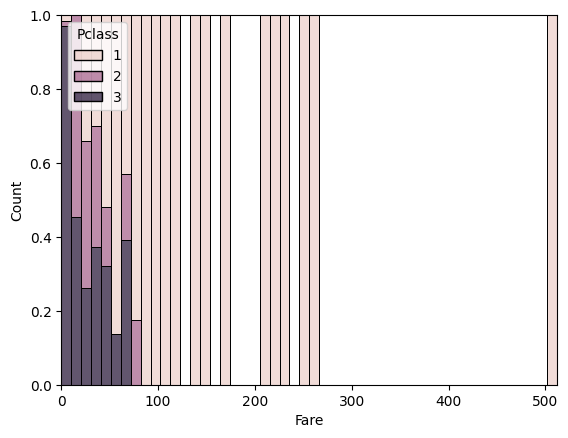

In [6]:
# チケット価格ごとのPclassを確認

sns.histplot(
    data,
    x="Fare",
    hue="Pclass",
    bins=50,
    multiple="fill"
)

plt.show()

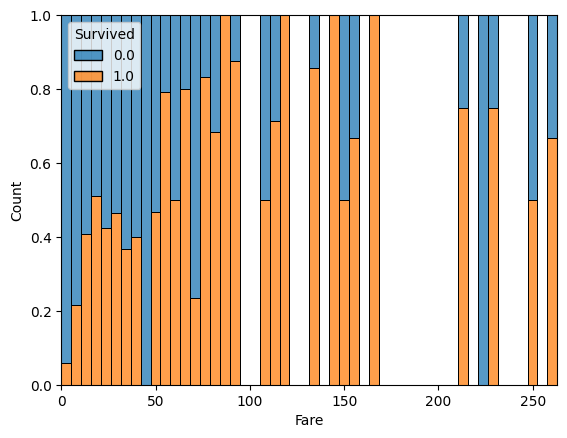

In [7]:
# チケット価格ごとの生存を確認

sns.histplot(
    # data,
    data=data[data["Fare"] < 300],
    x="Fare",
    hue="Survived",
    bins=50,
    multiple="fill"
)

plt.show()

In [ ]:
conn.close()